In [1]:
# TODO Save trial.user_attr range of parameters
# TODO For neuronal network visualizate by epoch
# TODO Summary protocol

In [3]:
from utilsOptuna import remove_study_from_storage

remove_study_from_storage('sqlite:///optuna_DL_exercise.db', 'xgboost_metadata1')

Study 'xgboost_metadata1' deleted successfully


In [4]:
from utilsOptuna import info_studies_from_storage

storage = 'sqlite:///optuna_DL_exercise.db'
print(f"Storage: {storage}")
info_studies_from_storage(storage)

Storage: sqlite:///optuna_DL_exercise.db


,study_name,best_score,description
0,fcnn_shallow_metadata1,0.818182,Shallow FCNN using metadata
1,fcnn_pca_embeddings1,0.705882,FCNN with Progressive Compression Architecture...
2,resnet18_pretrain_images1,0.840336,ResNet18 pretrained parameters
3,resnet18_layer4_images1,0.866397,ResNet18 layer4 parameters optimization
4,mmodal3_img1_meta1_emb1,0.873362,Multimodal: ResNet18 pre + fcnn_pca + metadata
5,logisticregression_metadata1,0.797463,Logistic Regression
6,randomforest_metadata1,0.807312,RandomForest


In [5]:
import optuna

storage = 'sqlite:///optuna_DL_exercise.db'
study_name = 'fcnn_pca_embeddings1'
study = optuna.load_study(
    study_name = study_name,
    storage = storage
)

In [ ]:
# info save in study
print(study.user_attrs)
# info save in trial
print(study.best_trial)

{'comments': 'FCNN with Progressive Compression Architecture for embeddings', 'dataset': 'poi_dataset.csv', 'preproc_data': "<class 'function'>", 'proc_features': "<class 'utilsFT.EmbeddingText'>", 'script': './fcnn_pca_embeddings1.py', 'split_test': {'test_size': 0.2}, 'split_val': {'test_size': 0.2}}
FrozenTrial(number=5, state=TrialState.COMPLETE, values=[0.7058823529411765], datetime_start=datetime.datetime(2025, 10, 10, 16, 1, 17, 605649), datetime_complete=datetime.datetime(2025, 10, 10, 16, 1, 31, 286180), params={'batch_size': 2, 'dropout_rate': 0.373818018663584, 'lr': 0.018760279275621405}, user_attrs={'criterion': "<class 'torch.nn.modules.loss.CrossEntropyLoss'>", 'device': 'cpu', 'fixed_params': {'data_loader': {}, 'model': {'input_size': 384, 'num_classes': 2}, 'optimizer': {}, 'criterion': {}}, 'model': "<class 'utilsNN.FCNN_pca'>", 'num_epochs': 10, 'optimizer': "<class 'torch.optim.adam.Adam'>", 'run': 'base_run', 'score': 'f1_score', 'train_results': {'test_loss': [42

0.5970464135021097

In [6]:
from utilsOptuna import info_runs_from_study

# get info for runs of a study
print(f"Storage: {storage}")
print(f"Study: {study_name}")
#info_runs_from_study(study.trials, extended=True)
info_runs_from_study(study.trials)


Storage: sqlite:///optuna_DL_exercise.db
Study: randomforest_metadata1


,run,num_trials,completed_trials,best_score
0,base_run,20,20,0.807312


In [7]:
from utilsOptuna import optuna_results

# output for best_trial
print(f"Storage: {storage}")
print(f"Study: {study_name}")
optuna_results(study)

Storage: sqlite:///optuna_DL_exercise.db
Study: randomforest_metadata1
Best trial:


NameError: name 'get_param_importances' is not defined

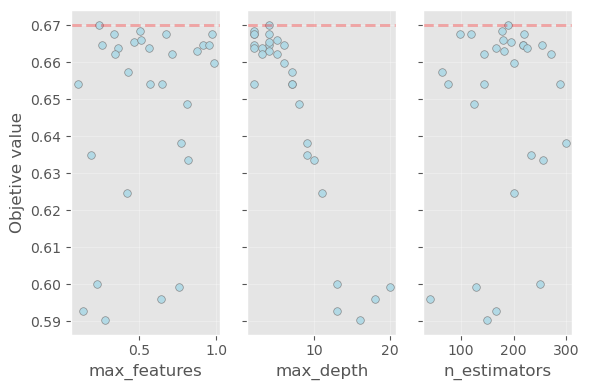

In [ ]:
from utilsOptuna import plot_slice

# TODO Custom plot_slice adapt log variables to axis scale
# TODO Custom plot_slice select highest trials
# TODO Select run
plot_slice(study) # Slice plot param vs objetiveValue

/tmp/ipykernel_100395/1588244805.py:5: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=['max_depth', 'n_estimators']) # 2D contour plot


<Axes: title={'center': 'Contour Plot'}, xlabel='max_depth', ylabel='n_estimators'>

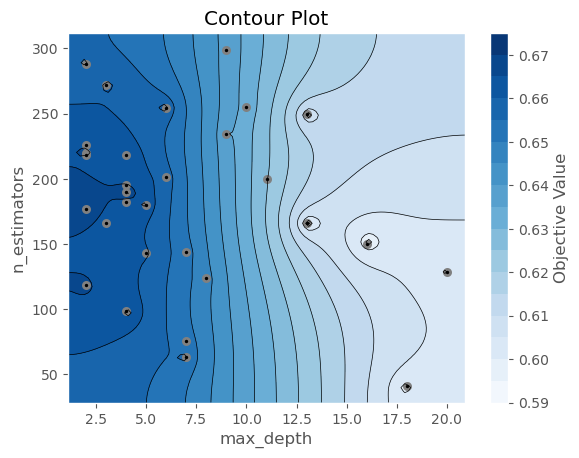

In [ ]:
import optuna

# TODO plot optimized hyperparameters
# TODO Make custom plot_contour. Highlight best result.
optuna.visualization.matplotlib.plot_contour(study, params=['max_depth', 'n_estimators']) # 2D contour plot


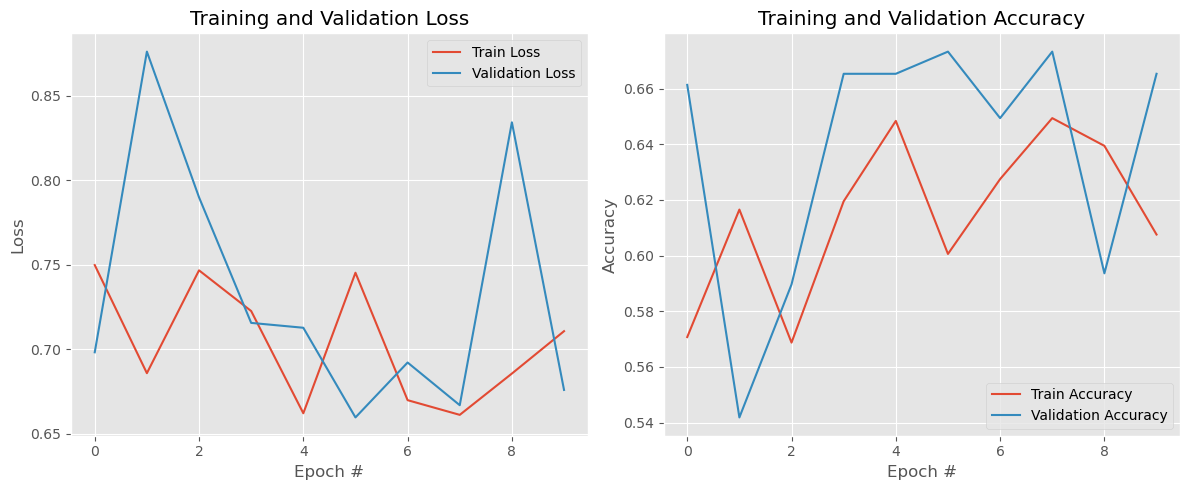

In [ ]:
from utilsOptuna import plot_train_nn

trial = study.best_trial
plot_train_nn(trial)

In [ ]:
# TODO How to calculate importance features. Is strange? Most importance to max_depth and n_estimators?
#optuna.visualization.matplotlib.plot_param_importances(study,evaluator=optuna.importance.FanovaImportanceEvaluator())